In [1]:
from pathlib import Path

import os
import numpy as np
import pandas as pd

order_tecnica = ["Zero-shot", "Few-shot", "Thought-Chain"]
order_llm = ["ChatGPT", "Gemini", "Claude", "DeepSeek"]

DATA_PATH = Path("Mapeamento da avaliação gráfica (2).xlsx")

out_dir = "/content/figuras"
os.makedirs(out_dir, exist_ok=True)

def _is_header_grafico(value: object) -> bool:
    s = str(value).strip().upper()
    return s.startswith("GR") and ("FICO" in s)

def parse_planilha_avaliacao_xlsx(path: str | Path) -> pd.DataFrame:
    raw = pd.read_excel(path, sheet_name=0, header=None, dtype=str).fillna("")

    coords = []
    for r in range(raw.shape[0]):
        for c in range(raw.shape[1]):
            if _is_header_grafico(raw.iat[r, c]):
                coords.append((r, c))

    if not coords:
        raise ValueError("Não encontrei o cabeçalho 'GRÁFICO' na planilha.")

    coords = sorted(coords)
    header_rows = sorted({r for r, _ in coords})

    if len(header_rows) < 3:
        raise ValueError(f"Esperava 3 blocos (técnicas), encontrei {len(header_rows)}.")

    entries = []

    for t_idx, header_r in enumerate(header_rows[:3]):
        tecnica = order_tecnica[t_idx]
        cols = sorted([c for r, c in coords if r == header_r])

        for rodada_idx, header_c in enumerate(cols[:3], start=1):
            r = header_r + 1
            while r < raw.shape[0]:
                g = str(raw.iat[r, header_c]).strip()
                if not g.isdigit():
                    break
                grafico = int(g)

                for k, llm in enumerate(order_llm):
                    ac = str(raw.iat[r, header_c + 1 + 2 * k]).strip()
                    lk = str(raw.iat[r, header_c + 2 + 2 * k]).strip()
                    acerto = int(ac) if ac.isdigit() else np.nan
                    likert = int(lk) if lk.isdigit() else np.nan
                    entries.append((rodada_idx, tecnica, llm, grafico, likert, acerto))

                r += 1

    df = pd.DataFrame(entries, columns=["rodada", "tecnica", "llm", "grafico", "likert", "acerto"])
    df["rodada"] = pd.Categorical(df["rodada"], categories=[1, 2, 3], ordered=True)
    df["tecnica"] = pd.Categorical(df["tecnica"], categories=order_tecnica, ordered=True)
    df["llm"] = pd.Categorical(df["llm"], categories=order_llm, ordered=True)

    df["grafico"] = pd.to_numeric(df["grafico"], errors="coerce")
    df["likert"] = pd.to_numeric(df["likert"], errors="coerce")
    df["acerto"] = pd.to_numeric(df["acerto"], errors="coerce")

    return df.sort_values(["rodada", "tecnica", "grafico", "llm"]).reset_index(drop=True)



In [ ]:
try:
    from google.colab import files

    if not DATA_PATH.exists():
        uploaded = files.upload()
        if uploaded:
            DATA_PATH = Path(next(iter(uploaded.keys())))
except Exception:
    pass

DATA_PATH


PosixPath('Mapeamento da avaliação gráfica (2).xlsx')

In [ ]:
df = parse_planilha_avaliacao_xlsx(DATA_PATH)
df.head(12)


,rodada,tecnica,llm,grafico,likert,acerto
0,1,Zero-shot,ChatGPT,1,3,0
1,1,Zero-shot,Gemini,1,3,0
2,1,Zero-shot,Claude,1,3,0
3,1,Zero-shot,DeepSeek,1,1,0
4,1,Zero-shot,ChatGPT,2,5,1
5,1,Zero-shot,Gemini,2,5,1
6,1,Zero-shot,Claude,2,5,1
7,1,Zero-shot,DeepSeek,2,5,1
8,1,Zero-shot,ChatGPT,3,4,1
9,1,Zero-shot,Gemini,3,2,0


In [ ]:
expected = 3 * 3 * 8 * 4
print("TOTAL_LINHAS:", len(df), "| EXPECTED:", expected)
display(df.groupby(["rodada", "tecnica"], observed=True).size().unstack(fill_value=0))
display(df.groupby(["rodada", "tecnica"], observed=True)["grafico"].nunique().unstack(fill_value=0))

display(df.groupby(["llm"], observed=True)["likert"].mean().sort_values(ascending=False).round(4).rename("média_likert"))
display(df.groupby(["llm"], observed=True)["acerto"].mean().sort_values(ascending=False).round(4).rename("taxa_acerto"))


TOTAL_LINHAS: 288 | EXPECTED: 288


tecnica,Zero-shot,Few-shot,Thought-Chain
rodada,,,
1,32,32,32
2,32,32,32
3,32,32,32


tecnica,Zero-shot,Few-shot,Thought-Chain
rodada,,,
1,8,8,8
2,8,8,8
3,8,8,8


,média_likert
llm,
ChatGPT,4.5694
Claude,4.3611
Gemini,4.2361
DeepSeek,2.9444


,taxa_acerto
llm,
ChatGPT,0.8472
Claude,0.7361
Gemini,0.6944
DeepSeek,0.3056


In [ ]:
print("Linhas:", len(df))
print("Rodadas:", df["rodada"].unique().tolist())
print("Técnicas:", df["tecnica"].unique().tolist())
print("LLMs:", df["llm"].unique().tolist())
print("Itens (gráfico):", sorted(df["grafico"].dropna().unique().astype(int).tolist()))

display(df.groupby(["rodada", "tecnica", "llm"], observed=True)["acerto"].mean().round(3).unstack("llm"))
display(df.groupby(["rodada", "tecnica", "llm"], observed=True)["likert"].mean().round(3).unstack("llm"))

best_by_round = df.groupby(["rodada", "llm"], observed=True)["likert"].mean().reset_index()
best_by_round = best_by_round.sort_values(["rodada", "likert"], ascending=[True, False]).groupby("rodada").head(1)
display(best_by_round)

best_by_tecnica = df.groupby(["tecnica", "llm"], observed=True)["likert"].mean().reset_index()
best_by_tecnica = best_by_tecnica.sort_values(["tecnica", "likert"], ascending=[True, False]).groupby("tecnica").head(1)
display(best_by_tecnica)


Linhas: 288
Rodadas: [1, 2, 3]
Técnicas: ['Zero-shot', 'Few-shot', 'Thought-Chain']
LLMs: ['ChatGPT', 'Gemini', 'Claude', 'DeepSeek']
Itens (gráfico): [1, 2, 3, 4, 5, 6, 7, 8]


llm                   ChatGPT  Gemini  Claude  DeepSeek
rodada tecnica                                         
1      Zero-shot        0.750   0.625   0.750     0.250
       Few-shot         0.625   0.875   0.625     0.250
       Thought-Chain    0.625   0.875   0.750     0.250
2      Zero-shot        0.875   0.625   0.750     0.375
       Few-shot         0.875   0.625   0.750     0.250
       Thought-Chain    1.000   0.500   0.875     0.250
3      Zero-shot        1.000   0.750   0.750     0.500
       Few-shot         0.875   0.625   0.750     0.375
       Thought-Chain    1.000   0.750   0.625     0.250

llm                   ChatGPT  Gemini  Claude  DeepSeek
rodada tecnica                                         
1      Zero-shot        4.375   3.875   4.500     2.500
       Few-shot         4.250   4.625   3.750     3.125
       Thought-Chain    4.125   4.750   4.500     3.000
2      Zero-shot        4.750   4.000   4.375     3.250
       Few-shot         4.375   4.125   4.500     2.500
       Thought-Chain    5.000   4.000   4.750     2.625
3      Zero-shot        5.000   4.375   4.500     3.375
       Few-shot         4.500   4.000   4.250     3.125
       Thought-Chain    4.750   4.375   4.125     3.000

/tmp/ipykernel_20631/1312409617.py:11: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,rodada,llm,likert
1,1,Gemini,4.416667
4,2,ChatGPT,4.708333
8,3,ChatGPT,4.750000


/tmp/ipykernel_20631/1312409617.py:15: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



,tecnica,llm,likert
0,Zero-shot,ChatGPT,4.708333
4,Few-shot,ChatGPT,4.375000
8,Thought-Chain,ChatGPT,4.625000


1

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

def salvar_heatmap_likert_por_tecnica(df):
    os.makedirs(out_dir, exist_ok=True)
    paths = []
    for t in order_tecnica:
        pivot = (
            df[df["tecnica"] == t]
            .pivot_table(index="grafico", columns="llm", values="likert", aggfunc="mean")
            .reindex(index=sorted(df["grafico"].unique()), columns=order_llm)
        )

        plt.figure(figsize=(6, 4))
        ax = sns.heatmap(
            pivot, annot=True, fmt=".0f",
            cmap="YlGnBu", vmin=1, vmax=5,
            cbar=True, cbar_kws={"label": "Likert (1–5)"}
        )
        ax.set_title(f"Heatmap Likert • {t}")
        ax.set_xlabel("LLM")
        ax.set_ylabel("Gráfico")
        plt.tight_layout()

        path = f"{out_dir}/01_heatmap_likert_{t}.png".replace(" ", "_")
        plt.savefig(path, dpi=250, bbox_inches="tight")
        plt.close()
        paths.append(path)
    return paths

salvar_heatmap_likert_por_tecnica(df)

/tmp/ipykernel_20631/2910472263.py:12: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/tmp/ipykernel_20631/2910472263.py:12: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior

/tmp/ipykernel_20631/2910472263.py:12: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



['/content/figuras/01_heatmap_likert_Zero-shot.png',
 '/content/figuras/01_heatmap_likert_Few-shot.png',
 '/content/figuras/01_heatmap_likert_Thought-Chain.png']

2

In [ ]:
def salvar_barras_media_likert_por_tecnica(df):
    os.makedirs(out_dir, exist_ok=True)
    agg = df.groupby(["tecnica","llm"], observed=True)["likert"].mean().reset_index()

    plt.figure(figsize=(9, 4.5))
    ax = sns.barplot(data=agg, x="tecnica", y="likert", hue="llm",
                     order=order_tecnica, hue_order=order_llm)
    ax.set_ylim(1,5)
    ax.set_xlabel("Técnica")
    ax.set_ylabel("Média Likert (5 itens)")
    ax.set_title("Média do Likert por LLM em cada técnica")
    ax.legend(title="LLM", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()

    path = f"{out_dir}/02_barras_media_likert_por_tecnica.png"
    plt.savefig(path, dpi=250, bbox_inches="tight")
    plt.close()
    return path

salvar_barras_media_likert_por_tecnica(df)


'/content/figuras/02_barras_media_likert_por_tecnica.png'

3


In [ ]:
def salvar_barras_tecnicas_dentro_llm(df):
    os.makedirs(out_dir, exist_ok=True)
    agg = df.groupby(["llm","tecnica"], observed=True)["likert"].mean().reset_index()
    paths = []

    for llm in order_llm:
        d = agg[agg["llm"] == llm]

        plt.figure(figsize=(6, 4))
        ax = sns.barplot(data=d, x="tecnica", y="likert", order=order_tecnica, color="#4C78A8")
        ax.set_ylim(1,5)
        ax.set_xlabel("Técnica")
        ax.set_ylabel("Média Likert (5 itens)")
        ax.set_title(f"Efeito da técnica • {llm}")
        plt.tight_layout()

        path = f"{out_dir}/03_barras_tecnica_dentro_{llm}.png"
        plt.savefig(path, dpi=250, bbox_inches="tight")
        plt.close()
        paths.append(path)

    return paths

salvar_barras_tecnicas_dentro_llm(df)

['/content/figuras/03_barras_tecnica_dentro_ChatGPT.png',
 '/content/figuras/03_barras_tecnica_dentro_Gemini.png',
 '/content/figuras/03_barras_tecnica_dentro_Claude.png',
 '/content/figuras/03_barras_tecnica_dentro_DeepSeek.png']

4

In [ ]:
def salvar_barras_taxa_acerto_por_tecnica(df):
    os.makedirs(out_dir, exist_ok=True)
    acc = df.groupby(["tecnica","llm"], observed=True)["acerto"].mean().reset_index()
    paths = []

    for t in order_tecnica:
        d = acc[acc["tecnica"] == t]

        plt.figure(figsize=(6.5, 4))
        ax = sns.barplot(data=d, x="llm", y="acerto", order=order_llm, color="#F58518")
        ax.set_ylim(0,1)
        ax.set_xlabel("LLM")
        ax.set_ylabel("Taxa de acerto (5 itens)")
        ax.set_title(f"Taxa de acerto por LLM • {t}")
        plt.tight_layout()

        path = f"{out_dir}/04_taxa_acerto_{t}.png".replace(" ", "_")
        plt.savefig(path, dpi=250, bbox_inches="tight")
        plt.close()
        paths.append(path)

    return paths

salvar_barras_taxa_acerto_por_tecnica(df)

['/content/figuras/04_taxa_acerto_Zero-shot.png',
 '/content/figuras/04_taxa_acerto_Few-shot.png',
 '/content/figuras/04_taxa_acerto_Thought-Chain.png']

5

In [ ]:
def salvar_ranking_por_item(df):
    os.makedirs(out_dir, exist_ok=True)
    tab_acerto = df.groupby(["grafico","llm"], observed=True)["acerto"].mean().unstack("llm").reindex(columns=order_llm)
    tab_likert = df.groupby(["grafico","llm"], observed=True)["likert"].mean().unstack("llm").reindex(columns=order_llm)

    ordem = tab_acerto.mean(axis=1).sort_values(ascending=True).index.tolist()
    tab_acerto = tab_acerto.reindex(index=ordem)
    tab_likert = tab_likert.reindex(index=ordem)

    paths = []

    plt.figure(figsize=(6.5, 4))
    ax = sns.heatmap(tab_acerto, annot=True, fmt=".2f", cmap="Reds_r", vmin=0, vmax=1,
                     cbar=True, cbar_kws={"label": "Taxa de acerto (0–1)"})
    ax.set_title("Ranking por item (acerto)\n(ordenado do mais difícil → mais fácil)")
    ax.set_xlabel("LLM")
    ax.set_ylabel("Gráfico")
    plt.tight_layout()
    p1 = f"{out_dir}/05_ranking_item_acerto.png"
    plt.savefig(p1, dpi=250, bbox_inches="tight")
    plt.close()
    paths.append(p1)

    plt.figure(figsize=(6.5, 4))
    ax = sns.heatmap(tab_likert, annot=True, fmt=".2f", cmap="YlGnBu", vmin=1, vmax=5,
                     cbar=True, cbar_kws={"label": "Likert (1–5)"})
    ax.set_title("Ranking por item (Likert)\n(mesma ordem do ranking por acerto)")
    ax.set_xlabel("LLM")
    ax.set_ylabel("Gráfico")
    plt.tight_layout()
    p2 = f"{out_dir}/05_ranking_item_likert.png"
    plt.savefig(p2, dpi=250, bbox_inches="tight")
    plt.close()
    paths.append(p2)

    return paths

salvar_ranking_por_item(df)

['/content/figuras/05_ranking_item_acerto.png',
 '/content/figuras/05_ranking_item_likert.png']

6

In [ ]:
!pip -q install plotly
import os
import numpy as np
import plotly.graph_objects as go

def sankey_llm_tecnica_status_colorido(df, out_dir="/content/figuras"):
    os.makedirs(out_dir, exist_ok=True)

    df2 = df.copy()
    df2["status"] = np.where(df2["acerto"] == 1, "Acerto", "Erro")

    llms = list(order_llm)
    tecnicas = list(order_tecnica)
    status = ["Acerto", "Erro"]

    labels = llms + tecnicas + status
    idx = {lab: i for i, lab in enumerate(labels)}

    llm_color = {
        "ChatGPT":  "rgba(76,120,168,0.65)",   # azul
        "Gemini":   "rgba(84,162,75,0.65)",    # verde
        "Claude":   "rgba(245,133,24,0.65)",   # laranja
        "DeepSeek": "rgba(175,122,197,0.65)",  # roxo
    }

    node_colors = []
    for lab in labels:
        if lab in llm_color:
            node_colors.append(llm_color[lab])
        elif lab in tecnicas:
            node_colors.append("rgba(220,220,220,0.85)")
        elif lab == "Acerto":
            node_colors.append("rgba(84,162,75,0.90)")
        else:  # Erro
            node_colors.append("rgba(229,99,99,0.90)")

    # LLM -> Técnica (contagem de itens)
    links1 = df2.groupby(["llm", "tecnica"], observed=True).size().reset_index(name="value")

    # Técnica -> Status POR LLM (para a cor “seguir” até o final)
    links2 = df2.groupby(["llm", "tecnica", "status"], observed=True).size().reset_index(name="value")

    source, target, value, colors = [], [], [], []

    for _, r in links1.iterrows():
        llm = r["llm"]
        source.append(idx[llm])
        target.append(idx[r["tecnica"]])
        value.append(int(r["value"]))
        colors.append(llm_color[llm])

    for _, r in links2.iterrows():
        llm = r["llm"]
        source.append(idx[r["tecnica"]])
        target.append(idx[r["status"]])
        value.append(int(r["value"]))
        colors.append(llm_color[llm])

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(
            pad=18, thickness=18,
            line=dict(color="black", width=0.3),
            label=labels,
            color=node_colors
        ),
        link=dict(
            source=source,
            target=target,
            value=value,
            color=colors
        )
    )])

    fig.update_layout(
        title_text="Fluxo: LLM → Técnica → (Acerto/Erro) • cores por LLM até o final",
        font_size=12
    )

    html_path = os.path.join(out_dir, "06_sankey_llm_tecnica_colorido_3_tecnicas.html")
    fig.write_html(html_path)
    fig.show()
    return html_path

sankey_llm_tecnica_status_colorido(df)

'/content/figuras/06_sankey_llm_tecnica_colorido_3_tecnicas.html'

In [ ]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

SAVE_FIGS = True
os.makedirs(out_dir, exist_ok=True)

def _finalize(fig_name: str, title: str):
    plt.title(title)
    plt.tight_layout()
    if SAVE_FIGS:
        plt.savefig(os.path.join(out_dir, fig_name), dpi=250, bbox_inches="tight")
    plt.show()
    plt.close()

agg_llm = df.groupby("llm", observed=True)["likert"].mean().reset_index()
agg_round = df.groupby("rodada", observed=True)["likert"].mean().reset_index()
agg_tec = df.groupby("tecnica", observed=True)["likert"].mean().reset_index()
agg_round_llm = df.groupby(["rodada", "llm"], observed=True)["likert"].mean().reset_index()
agg_tec_llm = df.groupby(["tecnica", "llm"], observed=True)["likert"].mean().reset_index()

pivot_tec_llm = (
    agg_tec_llm.pivot(index="tecnica", columns="llm", values="likert").reindex(index=order_tecnica, columns=order_llm)
)

pivot_round_llm = (
    agg_round_llm.pivot(index="rodada", columns="llm", values="likert").reindex(index=[1, 2, 3], columns=order_llm)
)

best_overall = df.groupby("llm", observed=True)["likert"].mean().sort_values(ascending=False)

mean_round_llm = df.groupby(["rodada", "llm"], observed=True)["likert"].mean().reset_index()
stability = mean_round_llm.groupby("llm", observed=True)["likert"].std().reset_index().rename(columns={"likert": "dp_média_entre_rodadas"})

acc_llm = df.groupby("llm", observed=True)["acerto"].mean().reset_index()
acc_round_llm = df.groupby(["rodada", "llm"], observed=True)["acerto"].mean().reset_index()
acc_tec_round = df.groupby(["tecnica", "rodada"], observed=True)["acerto"].mean().reset_index()


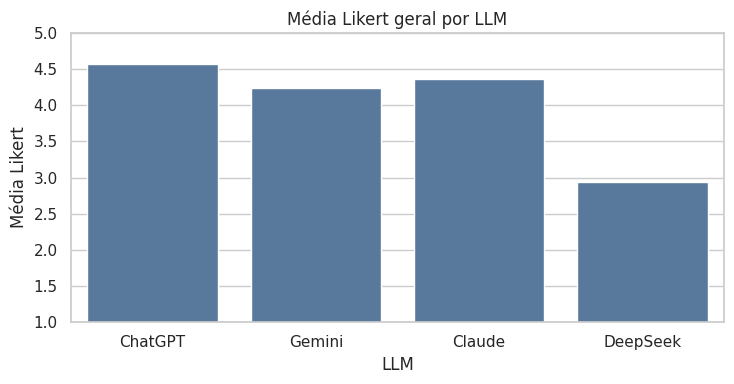

In [ ]:
plt.figure(figsize=(7.5, 4))
ax = sns.barplot(data=agg_llm, x="llm", y="likert", order=order_llm, color="#4C78A8")
ax.set_ylim(1, 5)
ax.set_xlabel("LLM")
ax.set_ylabel("Média Likert")
_finalize("A01_media_likert_geral_por_llm.png", "Média Likert geral por LLM")


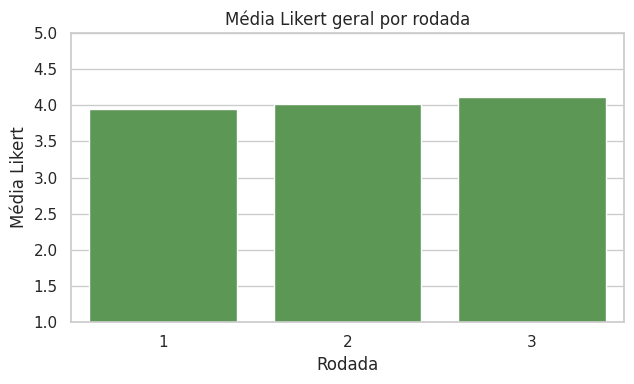

In [ ]:
plt.figure(figsize=(6.5, 4))
ax = sns.barplot(data=agg_round, x="rodada", y="likert", order=[1, 2, 3], color="#54A24B")
ax.set_ylim(1, 5)
ax.set_xlabel("Rodada")
ax.set_ylabel("Média Likert")
_finalize("A02_media_likert_geral_por_rodada.png", "Média Likert geral por rodada")


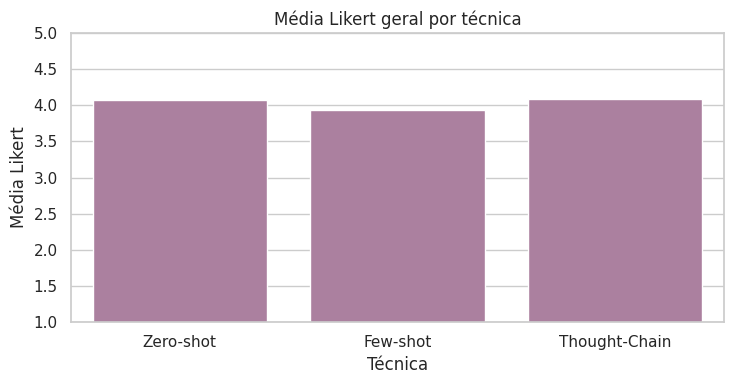

In [ ]:
plt.figure(figsize=(7.5, 4))
ax = sns.barplot(data=agg_tec, x="tecnica", y="likert", order=order_tecnica, color="#B279A2")
ax.set_ylim(1, 5)
ax.set_xlabel("Técnica")
ax.set_ylabel("Média Likert")
_finalize("A03_media_likert_geral_por_tecnica.png", "Média Likert geral por técnica")


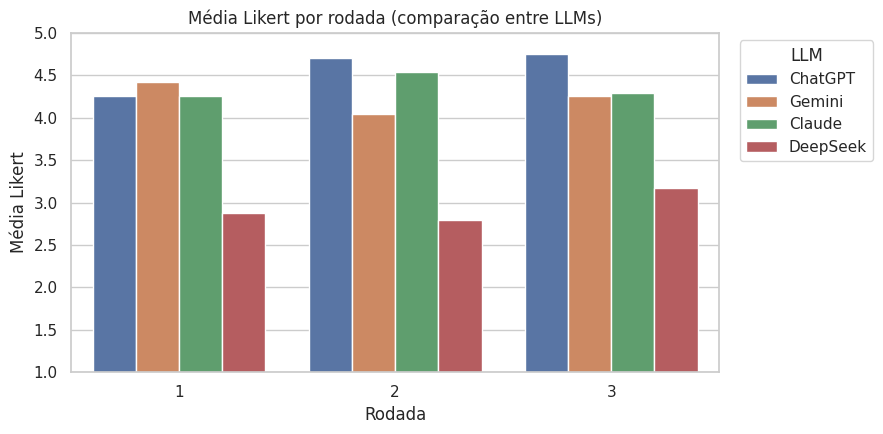

In [ ]:
plt.figure(figsize=(9, 4.5))
ax = sns.barplot(data=agg_round_llm, x="rodada", y="likert", hue="llm", order=[1, 2, 3], hue_order=order_llm)
ax.set_ylim(1, 5)
ax.set_xlabel("Rodada")
ax.set_ylabel("Média Likert")
ax.legend(title="LLM", bbox_to_anchor=(1.02, 1), loc="upper left")
_finalize("A04_media_likert_por_rodada_e_llm.png", "Média Likert por rodada (comparação entre LLMs)")


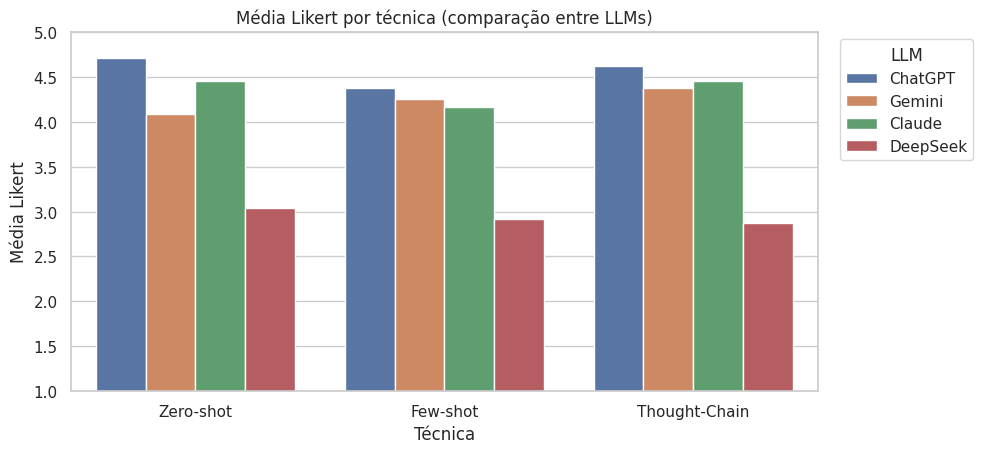

In [ ]:
plt.figure(figsize=(10, 4.7))
ax = sns.barplot(data=agg_tec_llm, x="tecnica", y="likert", hue="llm", order=order_tecnica, hue_order=order_llm)
ax.set_ylim(1, 5)
ax.set_xlabel("Técnica")
ax.set_ylabel("Média Likert")
ax.legend(title="LLM", bbox_to_anchor=(1.02, 1), loc="upper left")
_finalize("A05_media_likert_por_tecnica_e_llm.png", "Média Likert por técnica (comparação entre LLMs)")


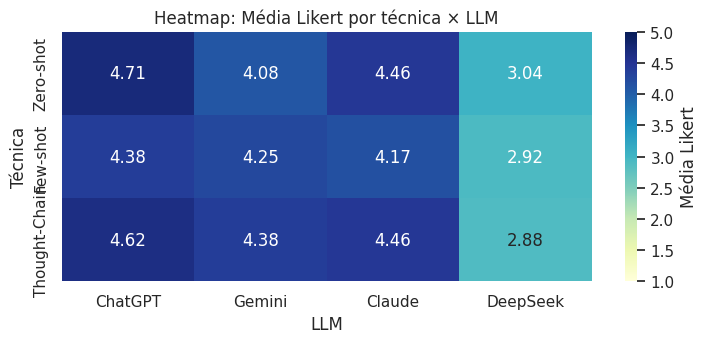

In [ ]:
plt.figure(figsize=(7.5, 3.6))
ax = sns.heatmap(pivot_tec_llm, annot=True, fmt=".2f", cmap="YlGnBu", vmin=1, vmax=5, cbar_kws={"label": "Média Likert"})
ax.set_xlabel("LLM")
ax.set_ylabel("Técnica")
_finalize("A06_heatmap_likert_tecnica_llm.png", "Heatmap: Média Likert por técnica × LLM")


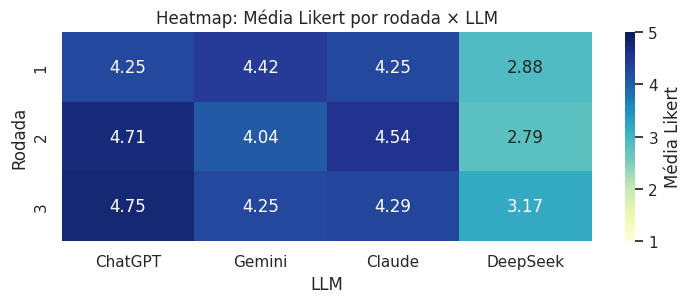

In [ ]:
plt.figure(figsize=(7.5, 3.2))
ax = sns.heatmap(pivot_round_llm, annot=True, fmt=".2f", cmap="YlGnBu", vmin=1, vmax=5, cbar_kws={"label": "Média Likert"})
ax.set_xlabel("LLM")
ax.set_ylabel("Rodada")
_finalize("A07_heatmap_likert_rodada_llm.png", "Heatmap: Média Likert por rodada × LLM")


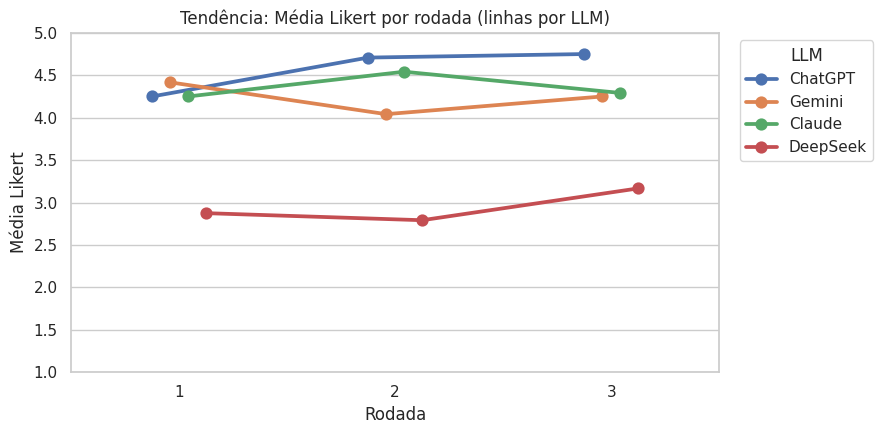

In [ ]:
plt.figure(figsize=(9, 4.5))
ax = sns.pointplot(data=agg_round_llm, x="rodada", y="likert", hue="llm", order=[1, 2, 3], hue_order=order_llm, dodge=0.25, markers="o")
ax.set_ylim(1, 5)
ax.set_xlabel("Rodada")
ax.set_ylabel("Média Likert")
ax.legend(title="LLM", bbox_to_anchor=(1.02, 1), loc="upper left")
_finalize("A08_tendencia_likert_por_rodada_e_llm.png", "Tendência: Média Likert por rodada (linhas por LLM)")


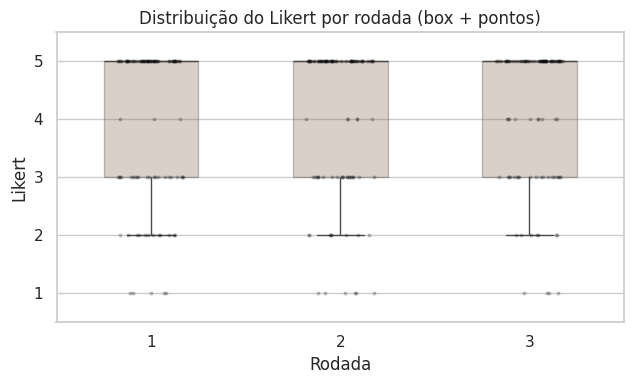

In [ ]:
plt.figure(figsize=(6.5, 4))
ax = sns.boxplot(
    data=df,
    x="rodada",
    y="likert",
    order=[1, 2, 3],
    width=0.5,
    showfliers=False,
    whis=(10, 90),
    boxprops={"alpha": 0.35},
    color="#9D755D",
)
sns.stripplot(
    data=df,
    x="rodada",
    y="likert",
    order=[1, 2, 3],
    color="black",
    alpha=0.25,
    jitter=0.18,
    size=2.8,
)
ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("Rodada")
ax.set_ylabel("Likert")
_finalize("B01_boxplot_likert_por_rodada.png", "Distribuição do Likert por rodada (box + pontos)")


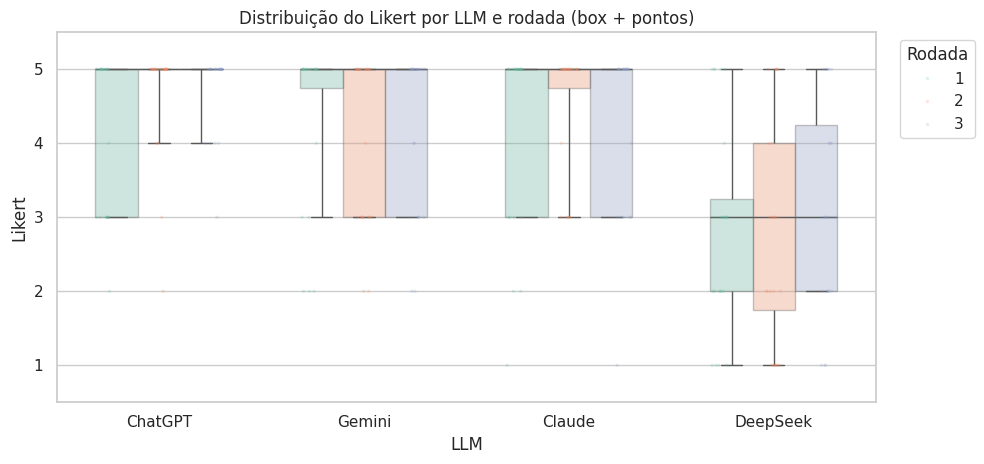

In [ ]:
plt.figure(figsize=(10, 4.8))
ax = sns.boxplot(
    data=df,
    x="llm",
    y="likert",
    hue="rodada",
    order=order_llm,
    hue_order=[1, 2, 3],
    width=0.62,
    showfliers=False,
    whis=(10, 90),
    boxprops={"alpha": 0.35},
    palette="Set2",
)
sns.stripplot(
    data=df,
    x="llm",
    y="likert",
    hue="rodada",
    order=order_llm,
    hue_order=[1, 2, 3],
    dodge=True,
    jitter=0.12,
    alpha=0.22,
    size=2.4,
    palette="Set2",
    linewidth=0,
)
ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("LLM")
ax.set_ylabel("Likert")

handles, labels = ax.get_legend_handles_labels()
by_label = {lab: h for h, lab in zip(handles, labels)}
wanted = ["1", "2", "3"]
ax.legend([by_label[w] for w in wanted if w in by_label], [w for w in wanted if w in by_label], title="Rodada", bbox_to_anchor=(1.02, 1), loc="upper left")

_finalize("B02_boxplot_likert_por_llm_e_rodada.png", "Distribuição do Likert por LLM e rodada (box + pontos)")


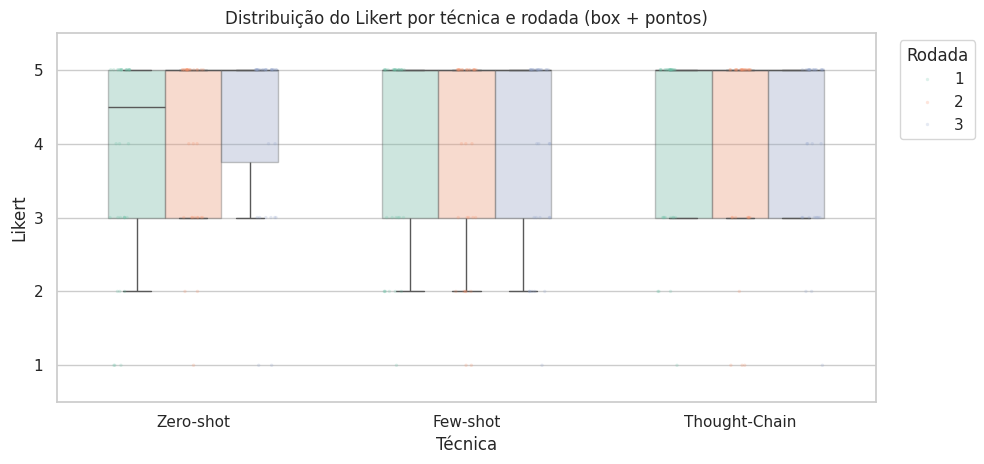

In [ ]:
plt.figure(figsize=(10, 4.8))
ax = sns.boxplot(
    data=df,
    x="tecnica",
    y="likert",
    hue="rodada",
    order=order_tecnica,
    hue_order=[1, 2, 3],
    width=0.62,
    showfliers=False,
    whis=(10, 90),
    boxprops={"alpha": 0.35},
    palette="Set2",
)
sns.stripplot(
    data=df,
    x="tecnica",
    y="likert",
    hue="rodada",
    order=order_tecnica,
    hue_order=[1, 2, 3],
    dodge=True,
    jitter=0.12,
    alpha=0.22,
    size=2.4,
    palette="Set2",
    linewidth=0,
)
ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("Técnica")
ax.set_ylabel("Likert")

handles, labels = ax.get_legend_handles_labels()
by_label = {lab: h for h, lab in zip(handles, labels)}
wanted = ["1", "2", "3"]
ax.legend([by_label[w] for w in wanted if w in by_label], [w for w in wanted if w in by_label], title="Rodada", bbox_to_anchor=(1.02, 1), loc="upper left")

_finalize("B03_boxplot_likert_por_tecnica_e_rodada.png", "Distribuição do Likert por técnica e rodada (box + pontos)")


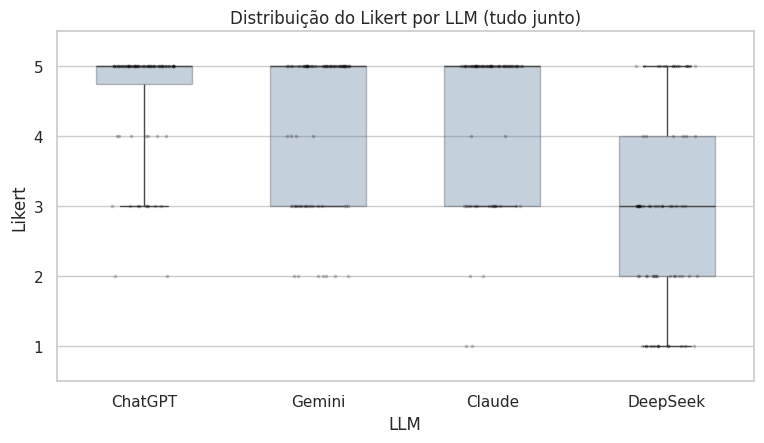

In [ ]:
plt.figure(figsize=(7.8, 4.6))
ax = sns.boxplot(
    data=df,
    x="llm",
    y="likert",
    order=order_llm,
    width=0.55,
    showfliers=False,
    whis=(10, 90),
    boxprops={"alpha": 0.35},
    color="#4C78A8",
)
sns.stripplot(
    data=df,
    x="llm",
    y="likert",
    order=order_llm,
    color="black",
    alpha=0.22,
    jitter=0.18,
    size=2.6,
)
ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("LLM")
ax.set_ylabel("Likert")
_finalize("B05_boxplot_likert_por_llm_tudo_junto.png", "Distribuição do Likert por LLM (tudo junto)")


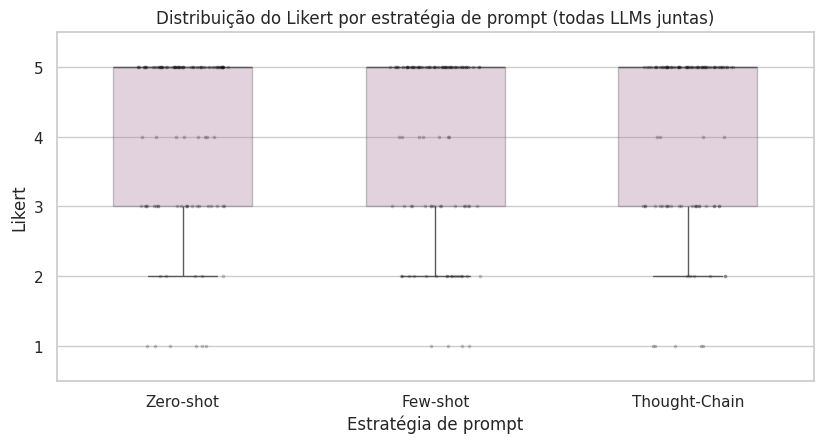

In [ ]:
plt.figure(figsize=(8.4, 4.6))
ax = sns.boxplot(
    data=df,
    x="tecnica",
    y="likert",
    order=order_tecnica,
    width=0.55,
    showfliers=False,
    whis=(10, 90),
    boxprops={"alpha": 0.35},
    color="#B279A2",
)
sns.stripplot(
    data=df,
    x="tecnica",
    y="likert",
    order=order_tecnica,
    color="black",
    alpha=0.22,
    jitter=0.18,
    size=2.6,
)
ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("Estratégia de prompt")
ax.set_ylabel("Likert")
_finalize("B06_boxplot_likert_por_tecnica_tudo_junto.png", "Distribuição do Likert por estratégia de prompt (todas LLMs juntas)")


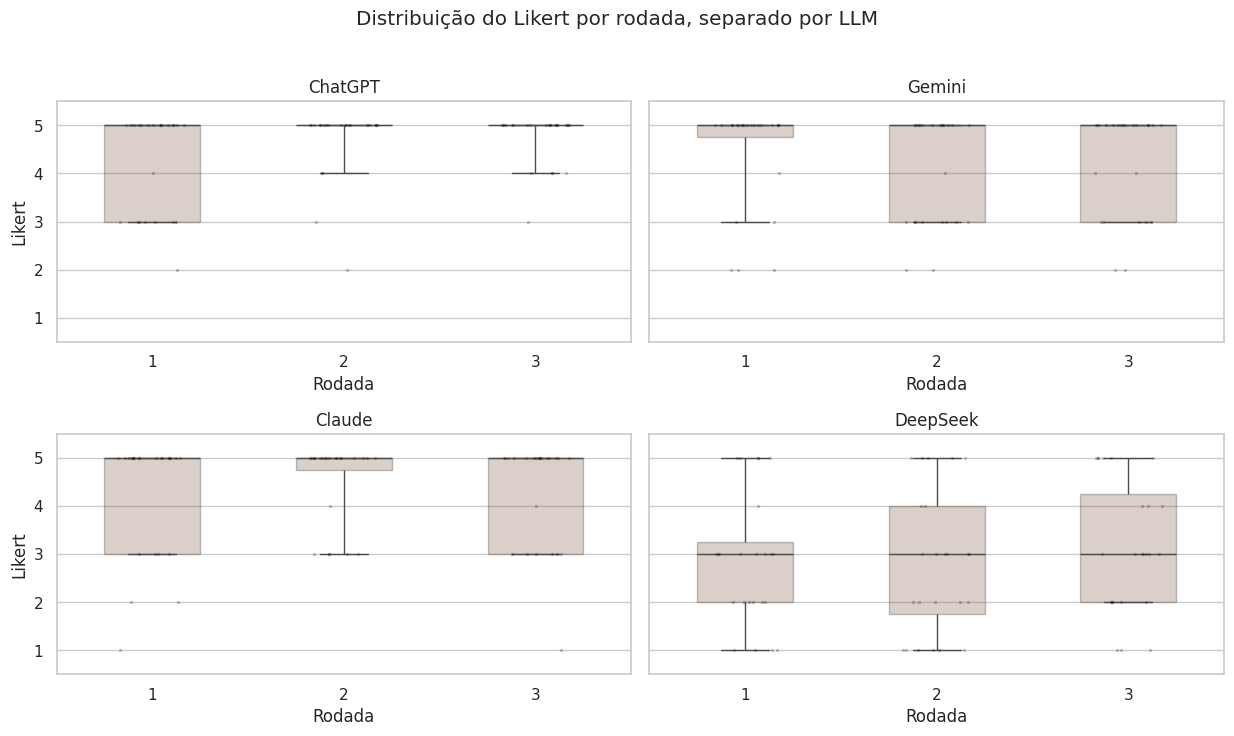

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12.5, 7.2), sharey=True)
axes = axes.flatten()

for ax, llm in zip(axes, order_llm):
    d = df[df["llm"] == llm]
    sns.boxplot(
        data=d,
        x="rodada",
        y="likert",
        order=[1, 2, 3],
        width=0.5,
        showfliers=False,
        whis=(10, 90),
        boxprops={"alpha": 0.35},
        color="#9D755D",
        ax=ax,
    )
    sns.stripplot(
        data=d,
        x="rodada",
        y="likert",
        order=[1, 2, 3],
        color="black",
        alpha=0.22,
        jitter=0.18,
        size=2.4,
        ax=ax,
    )
    ax.set_title(llm)
    ax.set_ylim(0.5, 5.5)
    ax.set_yticks([1, 2, 3, 4, 5])
    ax.set_xlabel("Rodada")
    ax.set_ylabel("Likert")

fig.suptitle("Distribuição do Likert por rodada, separado por LLM", y=1.02)
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(os.path.join(out_dir, "B07_boxplot_likert_por_rodada_separado_por_llm.png"), dpi=250, bbox_inches="tight")
plt.show()
plt.close(fig)


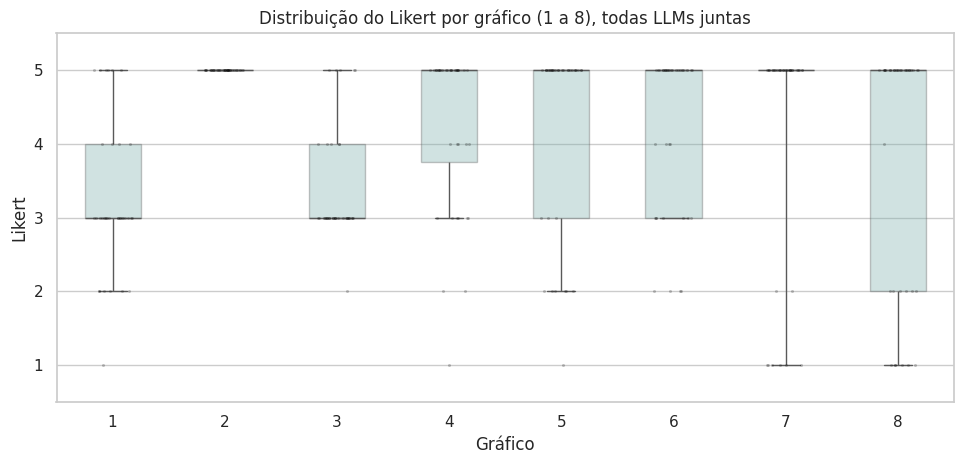

In [ ]:
graf_order = sorted(df["grafico"].dropna().astype(int).unique().tolist())

plt.figure(figsize=(9.8, 4.8))
ax = sns.boxplot(
    data=df,
    x="grafico",
    y="likert",
    order=graf_order,
    width=0.5,
    showfliers=False,
    whis=(10, 90),
    boxprops={"alpha": 0.35},
    color="#72B7B2",
)
sns.stripplot(
    data=df,
    x="grafico",
    y="likert",
    order=graf_order,
    color="black",
    alpha=0.22,
    jitter=0.18,
    size=2.2,
)
ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("Gráfico")
ax.set_ylabel("Likert")
_finalize("B08_boxplot_likert_por_grafico_tudo_junto.png", "Distribuição do Likert por gráfico (1 a 8), todas LLMs juntas")


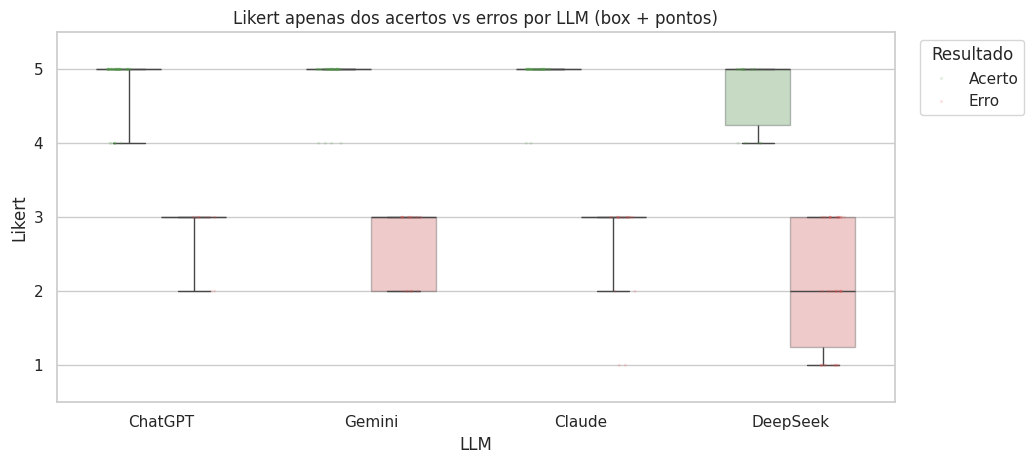

In [ ]:
df_status = df.copy()
df_status["status"] = np.where(df_status["acerto"] == 1, "Acerto", "Erro")

plt.figure(figsize=(10.5, 4.8))
ax = sns.boxplot(
    data=df_status,
    x="llm",
    y="likert",
    hue="status",
    order=order_llm,
    hue_order=["Acerto", "Erro"],
    width=0.62,
    showfliers=False,
    whis=(10, 90),
    boxprops={"alpha": 0.35},
    palette={"Acerto": "#54A24B", "Erro": "#E45756"},
)
sns.stripplot(
    data=df_status,
    x="llm",
    y="likert",
    hue="status",
    order=order_llm,
    hue_order=["Acerto", "Erro"],
    dodge=True,
    jitter=0.12,
    alpha=0.18,
    size=2.1,
    palette={"Acerto": "#54A24B", "Erro": "#E45756"},
    linewidth=0,
)
ax.set_ylim(0.5, 5.5)
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_xlabel("LLM")
ax.set_ylabel("Likert")

handles, labels = ax.get_legend_handles_labels()
by_label = {lab: h for h, lab in zip(handles, labels)}
wanted = ["Acerto", "Erro"]
ax.legend([by_label[w] for w in wanted if w in by_label], [w for w in wanted if w in by_label], title="Resultado", bbox_to_anchor=(1.02, 1), loc="upper left")

_finalize("B09_boxplot_likert_acerto_vs_erro_por_llm.png", "Likert apenas dos acertos vs erros por LLM (box + pontos)")


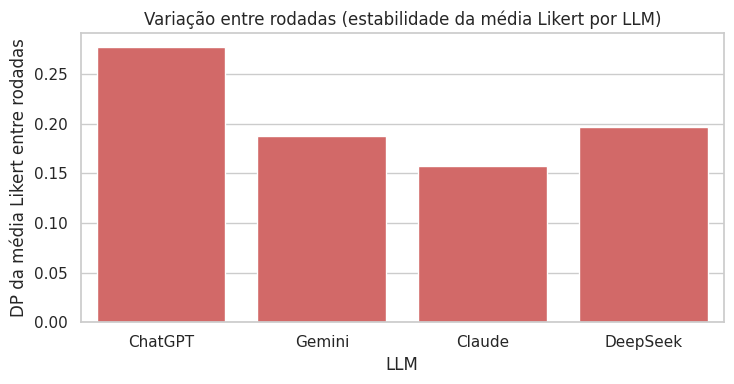

In [ ]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

out_dir = globals().get("out_dir", "/content/figuras")
SAVE_FIGS = globals().get("SAVE_FIGS", True)
os.makedirs(out_dir, exist_ok=True)

if "_finalize" not in globals():
    def _finalize(fig_name: str, title: str):
        plt.title(title)
        plt.tight_layout()
        if SAVE_FIGS:
            plt.savefig(os.path.join(out_dir, fig_name), dpi=250, bbox_inches="tight")
        plt.show()
        plt.close()

order_llm = globals().get("order_llm", sorted(df["llm"].astype(str).unique().tolist()))

mean_round_llm = df.groupby(["rodada", "llm"], observed=True)["likert"].mean().reset_index()
stability = mean_round_llm.groupby("llm", observed=True)["likert"].std().reset_index().rename(columns={"likert": "dp_média_entre_rodadas"})

plt.figure(figsize=(7.5, 4))
ax = sns.barplot(data=stability, x="llm", y="dp_média_entre_rodadas", order=order_llm, color="#E45756")
ax.set_xlabel("LLM")
ax.set_ylabel("DP da média Likert entre rodadas")
_finalize("B04_variacao_media_likert_por_llm.png", "Variação entre rodadas (estabilidade da média Likert por LLM)")


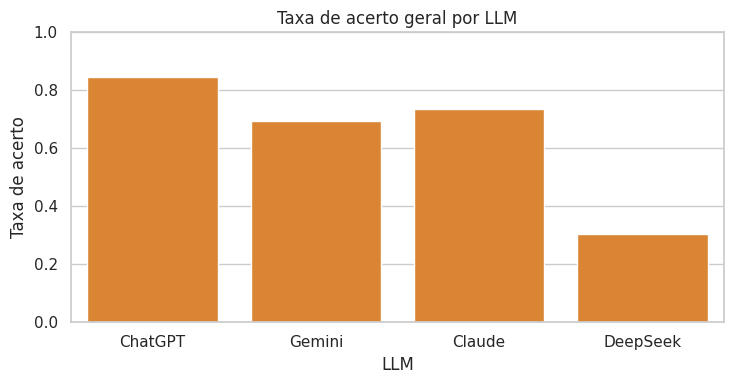

In [ ]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

out_dir = globals().get("out_dir", "/content/figuras")
SAVE_FIGS = globals().get("SAVE_FIGS", True)
os.makedirs(out_dir, exist_ok=True)

if "_finalize" not in globals():
    def _finalize(fig_name: str, title: str):
        plt.title(title)
        plt.tight_layout()
        if SAVE_FIGS:
            plt.savefig(os.path.join(out_dir, fig_name), dpi=250, bbox_inches="tight")
        plt.show()
        plt.close()

order_llm = globals().get("order_llm", sorted(df["llm"].astype(str).unique().tolist()))

acc_llm = df.groupby("llm", observed=True)["acerto"].mean().reset_index()

plt.figure(figsize=(7.5, 4))
ax = sns.barplot(data=acc_llm, x="llm", y="acerto", order=order_llm, color="#F58518")
ax.set_ylim(0, 1)
ax.set_xlabel("LLM")
ax.set_ylabel("Taxa de acerto")
_finalize("C01_taxa_acerto_geral_por_llm.png", "Taxa de acerto geral por LLM")


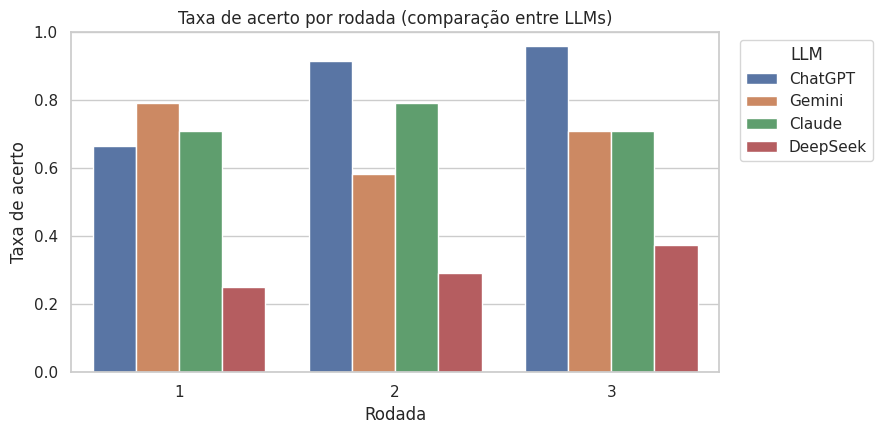

In [ ]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

out_dir = globals().get("out_dir", "/content/figuras")
SAVE_FIGS = globals().get("SAVE_FIGS", True)
os.makedirs(out_dir, exist_ok=True)

if "_finalize" not in globals():
    def _finalize(fig_name: str, title: str):
        plt.title(title)
        plt.tight_layout()
        if SAVE_FIGS:
            plt.savefig(os.path.join(out_dir, fig_name), dpi=250, bbox_inches="tight")
        plt.show()
        plt.close()

order_llm = globals().get("order_llm", sorted(df["llm"].astype(str).unique().tolist()))

acc_round_llm = df.groupby(["rodada", "llm"], observed=True)["acerto"].mean().reset_index()

plt.figure(figsize=(9, 4.5))
ax = sns.barplot(data=acc_round_llm, x="rodada", y="acerto", hue="llm", order=[1, 2, 3], hue_order=order_llm)
ax.set_ylim(0, 1)
ax.set_xlabel("Rodada")
ax.set_ylabel("Taxa de acerto")
ax.legend(title="LLM", bbox_to_anchor=(1.02, 1), loc="upper left")
_finalize("C02_taxa_acerto_por_rodada_e_llm.png", "Taxa de acerto por rodada (comparação entre LLMs)")


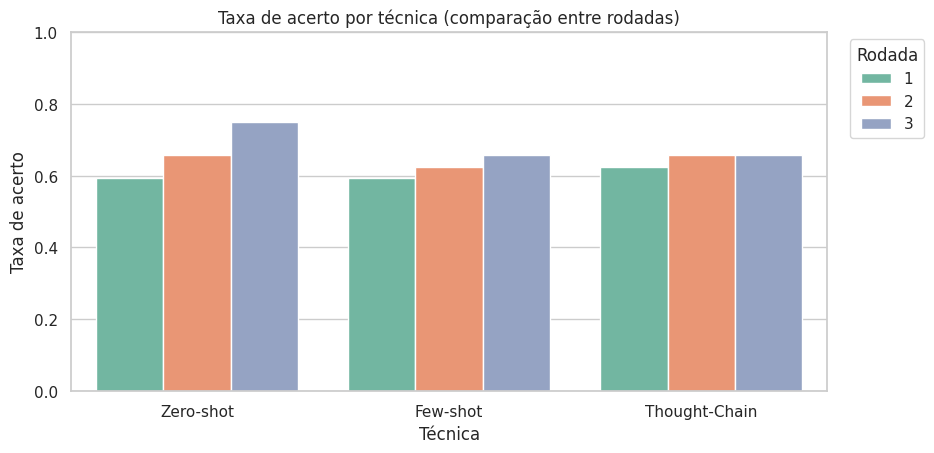

In [ ]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

out_dir = globals().get("out_dir", "/content/figuras")
SAVE_FIGS = globals().get("SAVE_FIGS", True)
os.makedirs(out_dir, exist_ok=True)

if "_finalize" not in globals():
    def _finalize(fig_name: str, title: str):
        plt.title(title)
        plt.tight_layout()
        if SAVE_FIGS:
            plt.savefig(os.path.join(out_dir, fig_name), dpi=250, bbox_inches="tight")
        plt.show()
        plt.close()

order_tecnica = globals().get("order_tecnica", sorted(df["tecnica"].astype(str).unique().tolist()))

acc_tec_round = df.groupby(["tecnica", "rodada"], observed=True)["acerto"].mean().reset_index()

plt.figure(figsize=(9.5, 4.7))
ax = sns.barplot(data=acc_tec_round, x="tecnica", y="acerto", hue="rodada", order=order_tecnica, hue_order=[1, 2, 3], palette="Set2")
ax.set_ylim(0, 1)
ax.set_xlabel("Técnica")
ax.set_ylabel("Taxa de acerto")
ax.legend(title="Rodada", bbox_to_anchor=(1.02, 1), loc="upper left")
_finalize("C03_taxa_acerto_por_tecnica_e_rodada.png", "Taxa de acerto por técnica (comparação entre rodadas)")


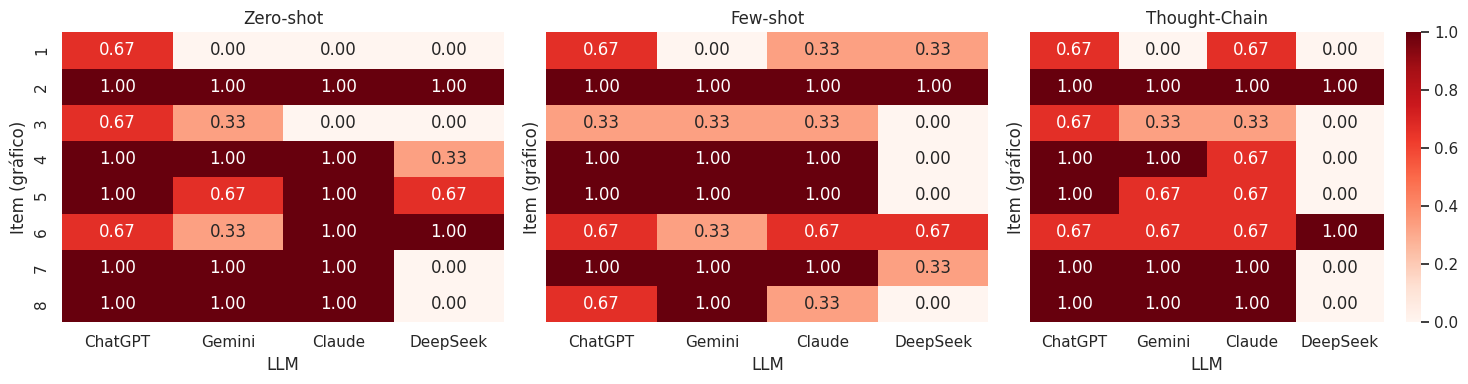

In [ ]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

out_dir = globals().get("out_dir", "/content/figuras")
SAVE_FIGS = globals().get("SAVE_FIGS", True)
os.makedirs(out_dir, exist_ok=True)

order_tecnica = globals().get("order_tecnica", sorted(df["tecnica"].astype(str).unique().tolist()))
order_llm = globals().get("order_llm", sorted(df["llm"].astype(str).unique().tolist()))

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, tecnica in zip(axes, order_tecnica):
    pivot_item = (
        df[df["tecnica"] == tecnica]
        .groupby(["grafico", "llm"], observed=True)["acerto"].mean().reset_index()
        .pivot(index="grafico", columns="llm", values="acerto")
        .reindex(columns=order_llm)
        .sort_index()
    )
    sns.heatmap(pivot_item, ax=ax, annot=True, fmt=".2f", cmap="Reds", vmin=0, vmax=1, cbar=ax is axes[-1])
    ax.set_title(tecnica)
    ax.set_xlabel("LLM")
    ax.set_ylabel("Item (gráfico)")

plt.tight_layout()
if SAVE_FIGS:
    plt.savefig(os.path.join(out_dir, "C04_heatmap_acerto_item_por_tecnica.png"), dpi=250, bbox_inches="tight")
plt.show()
plt.close()


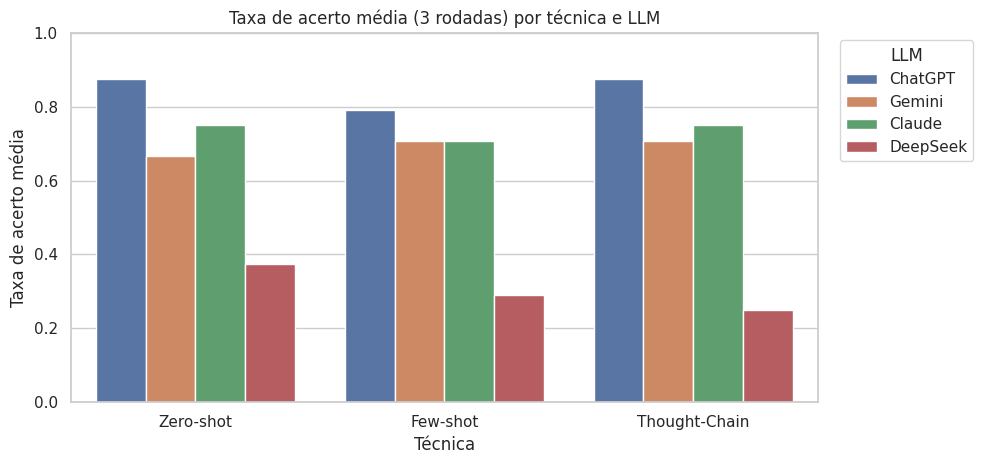

In [ ]:
import os

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

out_dir = globals().get("out_dir", "/content/figuras")
SAVE_FIGS = globals().get("SAVE_FIGS", True)
os.makedirs(out_dir, exist_ok=True)

if "_finalize" not in globals():
    def _finalize(fig_name: str, title: str):
        plt.title(title)
        plt.tight_layout()
        if SAVE_FIGS:
            plt.savefig(os.path.join(out_dir, fig_name), dpi=250, bbox_inches="tight")
        plt.show()
        plt.close()

order_tecnica = globals().get("order_tecnica", sorted(df["tecnica"].astype(str).unique().tolist()))
order_llm = globals().get("order_llm", sorted(df["llm"].astype(str).unique().tolist()))

acc_tec_llm = df.groupby(["tecnica", "llm"], observed=True)["acerto"].mean().reset_index()

plt.figure(figsize=(10, 4.8))
ax = sns.barplot(
    data=acc_tec_llm,
    x="tecnica",
    y="acerto",
    hue="llm",
    order=order_tecnica,
    hue_order=order_llm,
)
ax.set_ylim(0, 1)
ax.set_xlabel("Técnica")
ax.set_ylabel("Taxa de acerto média")
ax.legend(title="LLM", bbox_to_anchor=(1.02, 1), loc="upper left")
_finalize(
    "C05_taxa_acerto_media_por_tecnica_e_llm.png",
    "Taxa de acerto média (3 rodadas) por técnica e LLM",
)